<a href="https://colab.research.google.com/github/ParusSlava/Analysis_Cafe_Sales-/blob/main/EDA_Cafe_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis Cafe Sales

*Cafe Sales - Dirty Data for Cleaning Training*

**Overview**

The Dirty Cafe Sales dataset contains 10,000 rows of synthetic data representing sales transactions in a cafe. This dataset is intentionally "dirty," with missing values, inconsistent data, and errors introduced to provide a realistic scenario for data cleaning and exploratory data analysis (EDA). It can be used to practice cleaning techniques, data wrangling, and feature engineering.

**File Information**
 - File Name: dirty_cafe_sales.csv
 - Number of Rows: 10,000
 - Number of Columns: 8



-  `Transaction ID`	- A unique identifier for each transaction. Always present and unique.
- `Item` -	The name of the item purchased. May contain missing or invalid values (e.g., "ERROR").  

- `Quantity` -	The quantity of the item purchased. May contain missing or invalid values.

- `Price Per Unit` -	The price of a single unit of the item. May contain missing or invalid values.

- `Total Spent` - 	The total amount spent on the transaction. Calculated as Quantity * Price Per Unit.	  

- `Payment Method` - 	The method of payment used. May contain missing or invalid values (e.g., None, "UNKNOWN").  

- `Location` - 	The location where the transaction occurred. May contain missing or invalid values.  

- `Transaction Date ` -	The date of the transaction. May contain missing or incorrect values.  

`!pip install numpy pandas matplotlib`

In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading the dataset / Завантаження датасету

In [233]:
url = 'https://raw.githubusercontent.com/ParusSlava/Analysis_Cafe_Sales-/refs/heads/main/data/dirty_cafe_sales.csv'

df_origin = pd.read_csv(url)
df_origin.head()

# FILE_OUT = "data/cafe_sales_clean.csv"
FILE_OUT = "cafe_sales_clean.csv"

In [234]:
df = df_origin.copy()

## Primary diagnosis / Первинна діагностика

In [235]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [236]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [237]:
print('Data type (raw):\n')
df.dtypes

Data type (raw):



,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


Problem:
-  Numeric columns (Quantity, Price Per Unit, Total Spent)
-  Date columns (Transaction Date)

In [238]:
print('Missing values:\n')
missing = df.isnull().sum()
missing_pct = (missing / len(df) *100).round()
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
missing_report[missing_report['count'] > 0]

Missing values:



,count,%
Item,333,3.0
Quantity,138,1.0
Price Per Unit,179,2.0
Total Spent,173,2.0
Payment Method,2579,26.0
Location,3265,33.0
Transaction Date,159,2.0


In [239]:
print('Unique values:\n')

print('---Item---\n')
# print(df['Item'].value_counts(dropna=False))
display(df['Item'].value_counts(dropna=False))

print('\n---Payment Method---\n')
display(df['Payment Method'].value_counts(dropna=False))

print('\n---Location---\n')
display(df['Location'].value_counts(dropna=False))

Unique values:

---Item---



,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344



---Payment Method---



,count
Payment Method,
NaN,2579
Digital Wallet,2291
Credit Card,2273
Cash,2258
ERROR,306
UNKNOWN,293



---Location---



,count
Location,
NaN,3265
Takeaway,3022
In-store,3017
ERROR,358
UNKNOWN,338


In [240]:
print('Find lines with "ERROR" or "UNKNOWN"\n')
# df.isin(["ERROR" or "UNKNOWN"]).any()
display(df.isin(["ERROR" or "UNKNOWN"]).any())

mask_error = df.isin(["ERROR","UNKNOWN"]).any(axis=1)
print(f'\nFind lines with "ERROR" or "UNKNOWN": {mask_error.sum()}')

Find lines with "ERROR" or "UNKNOWN"



,0
Transaction ID,False
Item,True
Quantity,True
Price Per Unit,True
Total Spent,True
Payment Method,True
Location,True
Transaction Date,True



Find lines with "ERROR" or "UNKNOWN": 2845


In [241]:
print('Find lines with "ERROR" or "UNKNOWN"\n')
# df.isin(["ERROR" or "UNKNOWN"]).any()
display(df.isin(["ERROR","UNKNOWN"]).sum())

mask_error = df.isin(["ERROR","UNKNOWN"]).any(axis=1)
print(f'\nFind lines with "ERROR" or "UNKNOWN": {mask_error.sum()}')

Find lines with "ERROR" or "UNKNOWN"



,0
Transaction ID,0
Item,636
Quantity,341
Price Per Unit,354
Total Spent,329
Payment Method,599
Location,696
Transaction Date,301



Find lines with "ERROR" or "UNKNOWN": 2845


## Data Cleaning

Якщо не зроблена копія датасету - тут НЕОБХІДНО її створити!!! На етапі чистки, копія повинна бути.

- `df_origin` - origin dataset
- `df` - copy origin daraset

In [242]:
print('Rename columns:\n')

df.columns = df.columns.str.strip()
df = df.rename(columns = {
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_unit',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'
})

print(list(df.columns))

Rename columns:

['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


In [243]:
"_".join("     Transaction   Date   ".lower().split())

'transaction_date'

In [244]:
"   Transaction   Date   ".strip().lower().replace(" ", "_")

'transaction___date'

In [245]:
"   Transaction Date   ".strip().lower().replace(" ", "_")

'transaction_date'

In [246]:
df.columns.str.lower().str.split()

Index([  ['transaction_id'],             ['item'],         ['quantity'],
         ['price_per_unit'],      ['total_spent'],   ['payment_method'],
               ['location'], ['transaction_date']],
      dtype='object')

In [247]:
# 'ERROR'/'UNKNOWN' -> NaN
df.replace(['ERROR','UNKNOWN', 'error', 'unknown', ''], np.nan, inplace=True)
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [248]:
# Converting numeric columns
for col in ['quantity', 'price_per_unit', 'total_spent']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Date conversion
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')



In [249]:
print('Converting columns:\n')


df.dtypes

Converting columns:



,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]


In [250]:
new_df = pd.DataFrame({"quantity": [0, 3, 5, '', np.nan, "q"]})
# display(new_df)
# new_df.info()
pd.to_numeric(new_df['quantity'], errors='coerce')

,quantity
0,0.0
1,3.0
2,5.0
3,NaN
4,NaN
5,NaN


In [251]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

df.dtypes

,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]


In [252]:
# Extracting time signatures
df['year'] = df['transaction_date'].dt.year.astype('Int64')
df['month'] = df['transaction_date'].dt.month.astype('Int8')

# df['month_name'] = df['transaction_date'].dt.month_name()
df['month_name'] = df['transaction_date'].dt.strftime('%B')

df['weekday'] = df['transaction_date'].dt.day_name()
df['week'] = df['transaction_date'].dt.isocalendar().week.astype('Int8')

# display(df[['transaction_date','year', 'month', 'month_name', 'weekday', 'week']].dtypes)
df[['transaction_date','year', 'month', 'month_name', 'weekday', 'week']].head()

,transaction_date,year,month,month_name,weekday,week
0,2023-09-08,2023,9,September,Friday,36
1,2023-05-16,2023,5,May,Tuesday,20
2,2023-07-19,2023,7,July,Wednesday,29
3,2023-04-27,2023,4,April,Thursday,17
4,2023-06-11,2023,6,June,Sunday,23


In [253]:
# Restoring total_spent (quantity * price)

mask_recoverable = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable, 'total_spent'] = (
     df.loc[mask_recoverable, 'quantity'] *
     df.loc[mask_recoverable, 'price_per_unit']
)

print(f'Restoring total_spent: {mask_recoverable.sum()} string (quantity * price) ')




Restoring total_spent: 462 string (quantity * price) 


In [254]:
# dict of median prices
price_map = (
    df.dropna(subset=['item', 'price_per_unit'])
    .groupby('item')['price_per_unit']
    .median()
    .to_dict()
)

mask_price = df['price_per_unit'].isna() & df['item'].notna()

df.loc[mask_price, 'price_per_unit'] = df.loc[mask_price, 'item'].map(price_map)

print(f'Restoring price_per_unit: {mask_price.sum()} string (median per item) ')


Restoring price_per_unit: 479 string (median per item) 


In [255]:
type(df[mask_price])  # DataFrame
type(df[mask_price]['item'])  # Series
type(df[mask_price][['item', 'price_per_unit']])  # DataFrame

type(df.loc[mask_price, 'item'])  # Series
type(df.loc[mask_price, ['item', 'price_per_unit']])  # DataFrame

pandas.core.frame.DataFrame

In [256]:
import time
new_df = pd.DataFrame({
    'id': [0, 1, 2, 3, 4, 5, 6],
    'value': ['q', 'w', 'e', 'r', 't', 'y', 'u']
})

mask = new_df['id'] > 3

start = time.time()
new_df[mask]['value']

print(f'time df[mask]: {time.time() - start:.4f} sec')

time df[mask]: 0.0010 sec


In [257]:
%%time
new_df[mask]['value']

CPU times: user 657 µs, sys: 921 µs, total: 1.58 ms
Wall time: 1.49 ms


,value
4,t
5,y
6,u


In [258]:
new_df.loc[mask,'value'] = 100
new_df

,id,value
0,0,q
1,1,w
2,2,e
3,3,r
4,4,100
5,5,100
6,6,100


In [259]:
# Restoring total_spent (new price - median item)

mask_recoverable2 = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable2, 'total_spent'] = (
     df.loc[mask_recoverable2, 'quantity'] *
     df.loc[mask_recoverable2, 'price_per_unit']
)

print(f'Restoring total_spent: {mask_recoverable2.sum()} string (new price - median item) ')

Restoring total_spent: 17 string (new price - median item) 


In [260]:
# fillna item -> mode
mode_item = df['item'].mode()[0]

# df['item'].fillna(mode_item, inplace=True) # old version
df.fillna({'item': mode_item}, inplace=True)

In [261]:
df['item'].isna().sum()

np.int64(0)

In [262]:
# payment_method, location -> 'Unknown'
df.fillna(
    {
        'payment_method': 'Unknown',
        'location': 'Unknown'
    },
    inplace=True
)

In [263]:
# Delete transaction_date where NaT or NaN
before = len(df)

df.dropna(subset=['transaction_date', 'quantity'], inplace=True)

after = len(df)

print(f'Deleted {before - after} rows')

Deleted 914 rows


In [264]:
df.duplicated().sum() # 0
df.drop_duplicates(inplace=True)

In [265]:
(df.quantity <= 0).sum()
(df.price_per_unit <= 0).sum()
(df.total_spent <= 0).sum()

np.int64(0)

In [266]:
df[['item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date', 'year', 'month',
       'month_name', 'weekday', 'week']].duplicated().sum()

np.int64(192)

In [267]:
(df.price_per_unit <= 0).sum()
(df['quantity'].isna() & df['price_per_unit'].isna()).sum()

np.int64(0)

In [268]:
(df['quantity'].isna() | df['price_per_unit'].isna()).sum()

np.int64(48)

In [269]:
df.info()
#df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 9086 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9086 non-null   object        
 1   item              9086 non-null   object        
 2   quantity          9086 non-null   float64       
 3   price_per_unit    9038 non-null   float64       
 4   total_spent       9083 non-null   float64       
 5   payment_method    9086 non-null   object        
 6   location          9086 non-null   object        
 7   transaction_date  9086 non-null   datetime64[ns]
 8   year              9086 non-null   Int64         
 9   month             9086 non-null   Int8          
 10  month_name        9086 non-null   object        
 11  weekday           9086 non-null   object        
 12  week              9086 non-null   Int8          
dtypes: Int64(1), Int8(2), datetime64[ns](1), float64(3), object(6)
memory usage: 896.2+

In [270]:
# Restoring price_per_unit (total_spent / quantity)
mask_recoverable3 = (
    df['price_per_unit'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna()
)


df.loc[mask_recoverable3, 'price_per_unit'] = df.loc[mask_recoverable3, 'total_spent'] / df.loc[mask_recoverable3, 'quantity']

# mask_recoverable.sum()
print(f'Restoring price_per_unit: {mask_recoverable3.sum()} (total_spent / quantity)')


Restoring price_per_unit: 45 (total_spent / quantity)


In [271]:
df.dropna(subset=['total_spent'], inplace=True)

print(f"Delete rows with Nan (df['total_spent'].isna() & df['price_per_unit'].isna())")

Delete rows with Nan (df['total_spent'].isna() & df['price_per_unit'].isna())


In [272]:
df.isna().sum()

,0
transaction_id,0
item,0
quantity,0
price_per_unit,0
total_spent,0
payment_method,0
location,0
transaction_date,0
year,0
month,0


In [273]:
# Check quantity * price_per_unit = total_spent
mask_total_spent = (df.quantity * df.price_per_unit !=df.total_spent)
print(f"Uncorrect rows total_spent: {mask_total_spent.sum()}")


Uncorrect rows total_spent: 0


In [274]:
# Text fields are standertized (Text Case)
for col in ['item', 'payment_method', 'location']:
  df[col] = df[col].str.strip().str.title()
print("Text fields are standartized (Title Case)")


Text fields are standartized (Title Case)


# **Cleaning results**

In [275]:
# df_origin = name_your_origin_DataFrame
# df = name_your_clean_DataFrame

print("Cleaning results:\n")
print("=" * 20, "\n")

print(f"Rows before: {len(df_origin)}")
print(f"Rows after: {len(df)}")
print(f"Loss: {len(df_origin) - len(df)} ({(len(df_origin) - len(df)) / len(df_origin) * 100:.1f}%)")

print("\n---Residual gaps:---")
remaining = df.isna().sum()
print(remaining[remaining > 0] if remaining.any() else "No gaps")

print("\n---Data types after cleanup:---")
# print(df.dtypes)
display(df.dtypes)

print("\n---Statistics ---")
print(df[['quantity', 'price_per_unit', 'total_spent']].describe().round(2))

Cleaning results:


Rows before: 10000
Rows after: 9083
Loss: 917 (9.2%)

---Residual gaps:---
No gaps

---Data types after cleanup:---


,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]
year,Int64
month,Int8



---Statistics ---
       quantity  price_per_unit  total_spent
count   9083.00         9083.00      9083.00
mean       3.03            2.95         8.93
std        1.42            1.28         6.00
min        1.00            1.00         1.00
25%        2.00            2.00         4.00
50%        3.00            3.00         8.00
75%        4.00            4.00        12.00
max        5.00            5.00        25.00


In [276]:
# Season

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

# df[['month', 'season']].head()

In [277]:
# Is weekend

df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])

In [278]:
# Check amount category

df['spend_tier'] = pd.cut(
    df['total_spent'],
    bins=[0, 5, 10, 20, 1000],
    labels=['Low', 'Medium', 'High', 'Premium']
)


In [279]:
print("New attributes: season, is_weekend, spend_tier")

New attributes: season, is_weekend, spend_tier


In [280]:
df[df['total_spent'] > 20]

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week,season,is_weekend,spend_tier
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,2023,11,November,Tuesday,45,Autumn,False,Premium
51,TXN_6342161,Salad,5.0,5.0,25.0,Unknown,Takeaway,2023-01-08,2023,1,January,Sunday,1,Winter,True,Premium
52,TXN_8914892,Juice,5.0,5.0,25.0,Digital Wallet,Unknown,2023-03-15,2023,3,March,Wednesday,11,Spring,False,Premium
96,TXN_5220895,Salad,5.0,5.0,25.0,Cash,In-Store,2023-06-10,2023,6,June,Saturday,23,Summer,True,Premium
100,TXN_9517146,Juice,5.0,5.0,25.0,Cash,Takeaway,2023-10-30,2023,10,October,Monday,44,Autumn,False,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9791,TXN_1232346,Salad,5.0,5.0,25.0,Digital Wallet,In-Store,2023-01-04,2023,1,January,Wednesday,1,Winter,False,Premium
9805,TXN_9506076,Salad,5.0,5.0,25.0,Unknown,Unknown,2023-01-17,2023,1,January,Tuesday,3,Winter,False,Premium
9879,TXN_6393305,Salad,5.0,5.0,25.0,Digital Wallet,In-Store,2023-10-19,2023,10,October,Thursday,42,Autumn,False,Premium
9908,TXN_8922585,Salad,5.0,5.0,25.0,Credit Card,Unknown,2023-06-22,2023,6,June,Thursday,25,Summer,False,Premium


In [281]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week,season,is_weekend,spend_tier
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,September,Friday,36,Autumn,False,Low
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16,2023,5,May,Tuesday,20,Spring,False,High
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19,2023,7,July,Wednesday,29,Summer,False,Low
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,2023,4,April,Thursday,17,Spring,False,Medium
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-06-11,2023,6,June,Sunday,23,Summer,True,Low


## Fast EDA (verification graphs)

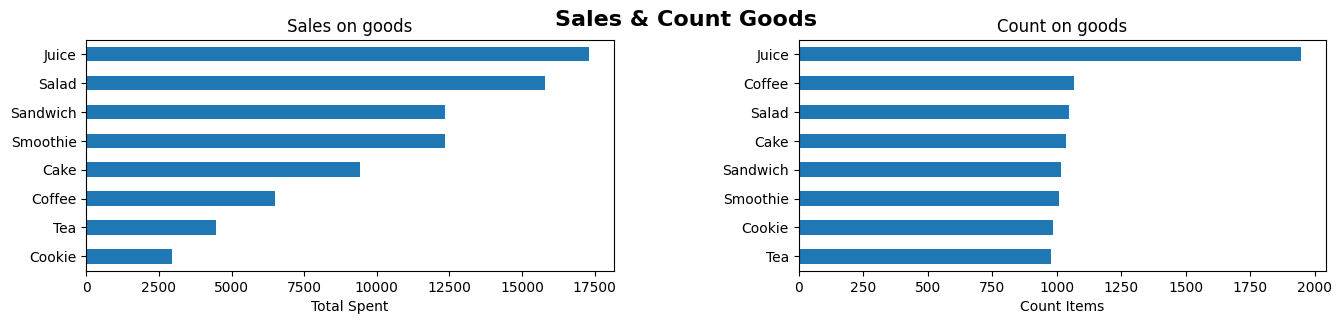

In [282]:
fig, axes = plt.subplots(1, 2, figsize=(16, 3))
fig.suptitle("Sales & Count Goods", fontsize=16, fontweight='bold')
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# total_spent per item

ax = axes[0]
df.groupby('item')['total_spent'].sum().sort_values().plot(kind='barh', ax=ax)
ax.set_title("Sales on goods")
ax.set_xlabel("Total Spent")
ax.set_ylabel("")

# count per item
ax = axes[1]
df['item'].value_counts().sort_values().plot(kind='barh', ax=ax)
ax.set_title("Count on goods")
ax.set_xlabel("Count Items")
ax.set_ylabel("")

plt.show()

In [283]:
set(list(df['month_name'].values))

{'April',
 'August',
 'December',
 'February',
 'January',
 'July',
 'June',
 'March',
 'May',
 'November',
 'October',
 'September'}

In [284]:
import calendar
print([calendar.month_name[i] for i in range(1, 13)])

['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


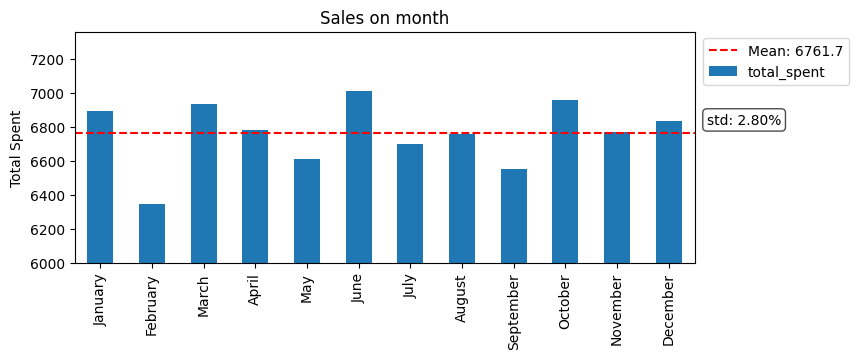

In [285]:
# Sales on month
fig = plt.figure(figsize=(8,3))
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December'
]

# print(df.groupby('month_name')['total_spent'].sum())
rev_month = df.groupby('month_name')['total_spent'].sum().reindex(
    [m for m in month_order if m in df['month_name'].unique()]
    )

rev_month.plot(kind='bar')

mean_value = rev_month.mean()
std_value = rev_month.std()
std_pct = (std_value / mean_value) * 100

# print(mean_value)
plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=1.5, label=f"Mean: {mean_value:.1f}")

plt.ylim(bottom=6000)
plt.title("Sales on month")
plt.xlabel("")
plt.ylabel("Total Spent")
plt.legend(bbox_to_anchor=(1.26, 1), loc='upper right')

plt.text(1.02, 0.6, f"std: {std_pct:.2f}%", transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round, pad=0.3', facecolor='white', alpha=0.7)
         )
plt.savefig('cafe_eda.png', dpi=150, bbox_inches='tight')
plt.show()

Додати графіки за власни поглядом

In [286]:
# Save figures
plt.savefig('cafe_eda.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# Saving a clean CSV for Tableau

In [287]:
# df['transaction_date'] = df_origin['Transaction Date'].copy()
# df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

In [290]:
# For Tableau bette date format: YYYY-MM-DD
try:
    df['transaction_date'] = df['transaction_date'].dt.strftime('%Y-%m-%d')
except:
    print("transaction_date was - ('%Y-%m-%d)\n")

# For Tableau: bool -> str
df['is_weekend'] = df['is_weekend'].map({
    True: 'Yes',
    False: 'No'
})

df.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')

print(f"Saved: {FILE_OUT}") # work in cilab ('data/file_name.csv')
print(f"Rows: {len(df)} | Columns: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")

transaction_date was - ('%Y-%m-%d)

Saved: cafe_sales_clean.csv
Rows: 9083 | Columns: 16
Columns: ['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date', 'year', 'month', 'month_name', 'weekday', 'week', 'season', 'is_weekend', 'spend_tier']


## SUMMARY REPORT

In [318]:
from enum import unique
print(f'Total revenue:             {df['total_spent'].sum():>14,.2f}')
print(f'Number of transactions:    {len(df):>14,}')
print(f'Average check:             {df['total_spent'].mean():>14,.2f}')
print(f'Median check:              {df['total_spent'].median():>14,.2f}')
print(f'Unique products:           {df['item'].nunique():>14,}')

all_location = df.loc[df['location'] != "Unknown", 'location']
print(f'Unique locations:          {all_location.nunique():>14,}')

top_item = df.groupby('item')['total_spent'].sum().idxmax()
print(f'Top profitable products:   {top_item:>14}')


# top_pay = df['payment_method'].value_counts()
# top_pay.drop('Unknown', errors='ignore').idxmax()

all_pay_method = df.loc[df['payment_method'] != "Unknown", 'payment_method']
top_pay = all_pay_method.value_counts().idxmax()

print(f'Unique payment method:     {all_pay_method.nunique():>14,}')
print(f'Top payment method:        {top_pay:>14}')




Total revenue:                  81,140.00
Number of transactions:             9,083
Average check:                       8.93
Median check:                        8.00
Unique products:                        8
Unique locations:                       2
Top profitable products:            Juice
Unique payment method:                  3
Top payment method:        Digital Wallet
